# CheXNet Training on 10% Subset

This notebook trains a **CheXNet (DenseNet121)** model on a 10% subset (~5,500 images) for baseline testing.

## 1. Setup and Imports

In [1]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.model_selection import train_test_split
from PIL import Image
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

# Device Configuration
device = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
print(f"Using device: {device}")

Using device: mps


## 2. Configuration

In [2]:
DATA_DIR = 'data/images'
SUBSET_METADATA_PATH = 'data/metadata_subset_10_percent.csv'

TARGET_CLASSES = [
    'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 
    'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 
    'No Finding', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax'
]

BATCH_SIZE = 16
LEARNING_RATE = 1e-4
EPOCHS = 2
IMG_SIZE = 224

## 3. Data Loading

In [3]:
if os.path.exists(SUBSET_METADATA_PATH):
    df = pd.read_csv(SUBSET_METADATA_PATH)
    
    def encode_labels(label_str):
        labels = str(label_str).split('|')
        return [1 if cls in labels else 0 for cls in TARGET_CLASSES]

    df['label_vec'] = df['Finding Labels'].apply(encode_labels)
    
    # Verify images exist
    if os.path.exists(DATA_DIR):
        available_images = set(os.listdir(DATA_DIR))
        df = df[df['Image Index'].isin(available_images)].reset_index(drop=True)
        print(f"Subset Image Count: {len(df)}")
    else:
        print(f"Error: {DATA_DIR} not found.")
else:
    print(f"Error: {SUBSET_METADATA_PATH} not found.")

Subset Image Count: 5500


In [4]:
class CheXNetDataset(Dataset):
    def __init__(self, dataframe, root_dir, transform=None):
        self.dataframe = dataframe
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        try:
            img_name = os.path.join(self.root_dir, self.dataframe.iloc[idx]['Image Index'])
            image = Image.open(img_name).convert('RGB')
            label = torch.tensor(self.dataframe.iloc[idx]['label_vec'], dtype=torch.float32)
            if self.transform: 
                image = self.transform(image)
            return image, label
        except Exception as e:
            return torch.zeros((3, IMG_SIZE, IMG_SIZE)), torch.zeros(len(TARGET_CLASSES))

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

if 'df' in globals() and len(df) > 0:
    train_df, val_df = train_test_split(df, test_size=0.15, random_state=42)

    # NOTE: num_workers is set to 0 for stability on macOS in Jupyter notebooks.
    # If you are on Linux/Windows, you can increase this for speed.
    train_loader = DataLoader(CheXNetDataset(train_df, DATA_DIR, train_transform), batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader = DataLoader(CheXNetDataset(val_df, DATA_DIR, val_transform), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    print(f"Train batches: {len(train_loader)}, Validation batches: {len(val_loader)}")

Train batches: 293, Validation batches: 52


## 4. Model Architecture

In [5]:
model = models.densenet121(weights='IMAGENET1K_V1')
in_features = model.classifier.in_features
model.classifier = nn.Linear(in_features, len(TARGET_CLASSES))
model = model.to(device)
print("Model initialized and moved to device.")

Model initialized and moved to device.


## 5. Training

In [6]:
criterion = nn.BCEWithLogitsLoss() 
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2)

def train_one_epoch(epoch, loader):
    model.train()
    total_loss = 0
    pbar = tqdm(loader, desc=f"Epoch {epoch+1} [Train]")
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        pbar.set_postfix(loss=loss.item())
    return total_loss / len(loader)

def validate(loader):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
    return total_loss / len(loader)

if 'train_loader' in globals():
    best_v_loss = float('inf')
    history = {'train_loss': [], 'val_loss': []}

    for epoch in range(EPOCHS):
        train_loss = train_one_epoch(epoch, train_loader)
        val_loss = validate(val_loader)
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        
        scheduler.step(val_loss)
        print(f"Epoch {epoch+1}: Train Loss = {train_loss:.4f}, Val Loss = {val_loss:.4f}")
        
        if val_loss < best_v_loss:
            best_v_loss = val_loss
            torch.save(model.state_dict(), 'chexnet_subset_best.pth')
            print("--- Saved Best Model ---")

    print("Training Complete.")
else:
    print("Error: train_loader not found. Please run Section 3.")

Epoch 1 [Train]:   0%|          | 0/293 [00:00<?, ?it/s]

Epoch 1: Train Loss = 0.2394, Val Loss = 0.1976
--- Saved Best Model ---


Epoch 2 [Train]:   0%|          | 0/293 [00:00<?, ?it/s]

Epoch 2: Train Loss = 0.1804, Val Loss = 0.1969
--- Saved Best Model ---
Training Complete.


## 6. Visualization

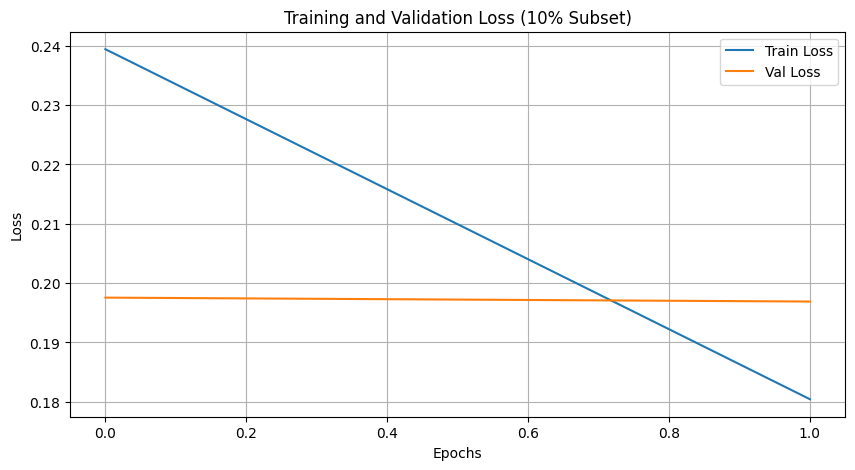

In [7]:
if 'history' in globals():
    plt.figure(figsize=(10, 5))
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.title('Training and Validation Loss (10% Subset)')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()